In [1]:
import warnings


warnings.filterwarnings("ignore")

# Optional specific suppressions
warnings.filterwarnings(
    "ignore",
    message="CUDA initialization"
)

warnings.filterwarnings(
    "ignore",
    message="IProgress not found"
)

import os
import gc
import json
import torch
import random
import numpy as np
import pandas as pd

from datasets import Dataset
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support
)

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    TrainingArguments,
    Trainer,
    DataCollatorForLanguageModeling
)


print("Torch Version:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Running on CPU")

Torch Version: 2.3.1+cu121
CUDA Available: True
GPU: NVIDIA GeForce RTX 3090


In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Seed set to:", SEED)

Seed set to: 42


In [3]:
BASE_PATH = "/home/jovyan/work"

COURSE_PATH = f"{BASE_PATH}/course_balanced.csv"
TEACHER_PATH = f"{BASE_PATH}/teacher_balanced.csv"
UNIVERSITY_PATH = f"{BASE_PATH}/university_balanced.csv"

OUTPUT_DIR = f"{BASE_PATH}/llama_multidomain_output"

os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Output directory created:")
print(OUTPUT_DIR)

Output directory created:
/home/jovyan/work/llama_multidomain_output


In [4]:
course_df = pd.read_csv(COURSE_PATH)
teacher_df = pd.read_csv(TEACHER_PATH)
university_df = pd.read_csv(UNIVERSITY_PATH)

print("Course Shape:", course_df.shape)
print("Teacher Shape:", teacher_df.shape)
print("University Shape:", university_df.shape)

Course Shape: (4218, 4)
Teacher Shape: (4218, 4)
University Shape: (4218, 4)


In [5]:
course_df["domain"] = "course"
teacher_df["domain"] = "teacher"
university_df["domain"] = "university"

print(course_df.head())

                                              review              aspect  \
0  This course was amazing. For the first time, t...              course   
1  This course was amazing. For the first time, t...         lab partner   
2  Extremely boring and lectures were useless, bu...            lectures   
3  Extremely boring and lectures were useless, bu...  information taught   
4  Cool course content, requires effort to get it...      course content   

  sentiment  domain  
0  positive  course  
1  positive  course  
2  negative  course  
3  positive  course  
4  positive  course  


In [6]:
def add_row_id(df, domain_name):

    df = df.reset_index(drop=True)

    df["row_id"] = [
        f"{domain_name}_{i}" for i in range(len(df))
    ]

    return df

course_df = add_row_id(course_df, "course")
teacher_df = add_row_id(teacher_df, "teacher")
university_df = add_row_id(university_df, "university")

print(course_df[["row_id", "review", "aspect", "sentiment"]].head())

     row_id                                             review  \
0  course_0  This course was amazing. For the first time, t...   
1  course_1  This course was amazing. For the first time, t...   
2  course_2  Extremely boring and lectures were useless, bu...   
3  course_3  Extremely boring and lectures were useless, bu...   
4  course_4  Cool course content, requires effort to get it...   

               aspect sentiment  
0              course  positive  
1         lab partner  positive  
2            lectures  negative  
3  information taught  positive  
4      course content  positive  


In [7]:
label2id = {
    "negative": 0,
    "neutral": 1,
    "positive": 2
}

id2label = {
    0: "negative",
    1: "neutral",
    2: "positive"
}

# Convert sentiment labels to integers
course_df["label"] = course_df["sentiment"].map(label2id)
teacher_df["label"] = teacher_df["sentiment"].map(label2id)
university_df["label"] = university_df["sentiment"].map(label2id)

print(course_df[["sentiment", "label"]].head())

  sentiment  label
0  positive      2
1  positive      2
2  negative      0
3  positive      2
4  positive      2


In [8]:
from sklearn.model_selection import train_test_split

def split_domain(df):

    train_df, test_df = train_test_split(
        df,
        test_size=0.2,
        stratify=df["label"],
        random_state=SEED
    )

    return train_df, test_df

course_train, course_test = split_domain(course_df)
teacher_train, teacher_test = split_domain(teacher_df)
university_train, university_test = split_domain(university_df)

print("Course Train/Test:", course_train.shape, course_test.shape)
print("Teacher Train/Test:", teacher_train.shape, teacher_test.shape)
print("University Train/Test:", university_train.shape, university_test.shape)

Course Train/Test: (3374, 6) (844, 6)
Teacher Train/Test: (3374, 6) (844, 6)
University Train/Test: (3374, 6) (844, 6)


In [9]:
BASE_PATH = "/home/jovyan/work"


DISSERTATION_PATH = f"{BASE_PATH}/Dissertation"


SHARED_TEST_PATH = f"{DISSERTATION_PATH}/shared_test_sets"

MULTIDOMAIN_LLAMA_PATH = f"{DISSERTATION_PATH}/multidomain_llama"

CROSSDOMAIN_LLAMA_PATH = f"{DISSERTATION_PATH}/crossdomain_llama"

MULTIDOMAIN_MODERNBERT_PATH = f"{DISSERTATION_PATH}/multidomain_modernbert"

PLOTS_PATH = f"{DISSERTATION_PATH}/plots"

METRICS_PATH = f"{DISSERTATION_PATH}/metrics"

ERROR_ANALYSIS_PATH = f"{DISSERTATION_PATH}/error_analysis"

DISAGREEMENT_ANALYSIS_PATH = f"{DISSERTATION_PATH}/disagreement_analysis"

MODELS_PATH = f"{DISSERTATION_PATH}/saved_models"


os.makedirs(DISSERTATION_PATH, exist_ok=True)

os.makedirs(SHARED_TEST_PATH, exist_ok=True)

os.makedirs(MULTIDOMAIN_LLAMA_PATH, exist_ok=True)

os.makedirs(CROSSDOMAIN_LLAMA_PATH, exist_ok=True)

os.makedirs(MULTIDOMAIN_MODERNBERT_PATH, exist_ok=True)

os.makedirs(PLOTS_PATH, exist_ok=True)

os.makedirs(METRICS_PATH, exist_ok=True)

os.makedirs(ERROR_ANALYSIS_PATH, exist_ok=True)

os.makedirs(DISAGREEMENT_ANALYSIS_PATH, exist_ok=True)

os.makedirs(MODELS_PATH, exist_ok=True)


print("Dissertation directory structure created successfully.\n")

print("Main Path:")
print(DISSERTATION_PATH)

print("\nCreated Subfolders:")
print("- shared_test_sets")
print("- multidomain_llama")
print("- crossdomain_llama")
print("- multidomain_modernbert")
print("- plots")
print("- metrics")
print("- error_analysis")
print("- disagreement_analysis")
print("- saved_models")

Dissertation directory structure created successfully.

Main Path:
/home/jovyan/work/Dissertation

Created Subfolders:
- shared_test_sets
- multidomain_llama
- crossdomain_llama
- multidomain_modernbert
- plots
- metrics
- error_analysis
- disagreement_analysis
- saved_models


In [10]:
course_test.to_csv(
    f"{SHARED_TEST_PATH}/course_test_shared.csv",
    index=False
)

teacher_test.to_csv(
    f"{SHARED_TEST_PATH}/teacher_test_shared.csv",
    index=False
)

university_test.to_csv(
    f"{SHARED_TEST_PATH}/university_test_shared.csv",
    index=False
)

print("Shared test sets saved successfully.")

print("\nSaved Files:")
print("- course_test_shared.csv")
print("- teacher_test_shared.csv")
print("- university_test_shared.csv")

Shared test sets saved successfully.

Saved Files:
- course_test_shared.csv
- teacher_test_shared.csv
- university_test_shared.csv


In [11]:
multidomain_train_df = pd.concat(
    [
        course_train,
        teacher_train,
        university_train
    ],
    ignore_index=True
)

print("Multidomain Train Dataset Shape:")
print(multidomain_train_df.shape)

print("\nDomain Distribution:")
print(multidomain_train_df["domain"].value_counts())

Multidomain Train Dataset Shape:
(10122, 6)

Domain Distribution:
domain
course        3374
teacher       3374
university    3374
Name: count, dtype: int64


In [12]:
datasets_dict = {
    "course": course_df,
    "teacher": teacher_df,
    "university": university_df
}

for name, df in datasets_dict.items():

    print("=" * 60)
    print(f"{name.upper()} DATASET OVERVIEW")
    print("=" * 60)

    # Shape
    print("\nDataset Shape:")
    print(df.shape)

    # Columns
    print("\nColumns:")
    print(df.columns.tolist())

    # Missing values
    print("\nMissing Values:")
    print(df.isnull().sum())

    # Duplicate rows
    print("\nDuplicate Rows:")
    print(df.duplicated().sum())

    # Unique aspects
    print("\nUnique Aspects:")
    print(df["aspect"].nunique())

    # Sentiment distribution
    print("\nSentiment Distribution:")
    print(df["sentiment"].value_counts())

    # Average review length
    avg_words = df["review"].apply(
        lambda x: len(str(x).split())
    ).mean()

    print("\nAverage Review Length (words):")
    print(round(avg_words, 2))

    # Display sample rows
    print("\nSample Rows:")
    display(
        df[
            [
                "row_id",
                "review",
                "aspect",
                "sentiment",
                "domain"
            ]
        ].head()
    )

    print("\n\n")

COURSE DATASET OVERVIEW

Dataset Shape:
(4218, 6)

Columns:
['review', 'aspect', 'sentiment', 'domain', 'row_id', 'label']

Missing Values:
review       0
aspect       0
sentiment    0
domain       0
row_id       0
label        0
dtype: int64

Duplicate Rows:
0

Unique Aspects:
1485

Sentiment Distribution:
sentiment
positive    2039
negative    1456
neutral      723
Name: count, dtype: int64

Average Review Length (words):
50.17

Sample Rows:


,row_id,review,aspect,sentiment,domain
0,course_0,"This course was amazing. For the first time, t...",course,positive,course
1,course_1,"This course was amazing. For the first time, t...",lab partner,positive,course
2,course_2,"Extremely boring and lectures were useless, bu...",lectures,negative,course
3,course_3,"Extremely boring and lectures were useless, bu...",information taught,positive,course
4,course_4,"Cool course content, requires effort to get it...",course content,positive,course





TEACHER DATASET OVERVIEW

Dataset Shape:
(4218, 6)

Columns:
['review', 'aspect', 'sentiment', 'domain', 'row_id', 'label']

Missing Values:
review       0
aspect       0
sentiment    0
domain       0
row_id       0
label        0
dtype: int64

Duplicate Rows:
0

Unique Aspects:
1697

Sentiment Distribution:
sentiment
positive    2345
negative    1437
neutral      436
Name: count, dtype: int64

Average Review Length (words):
64.56

Sample Rows:


,row_id,review,aspect,sentiment,domain
0,teacher_0,"First of all, shoutout to Scott Hopkins for th...",Scott Hopkins,positive,teacher
1,teacher_1,this lady is a very harsh grader and talks ent...,this lady,negative,teacher
2,teacher_2,"If you are going into the health sciences, you...",this class,positive,teacher
3,teacher_3,Terrible teacher! Does not care about anyone o...,teacher,negative,teacher
4,teacher_4,his a good teacher but extermely difficult... ...,teacher,positive,teacher





UNIVERSITY DATASET OVERVIEW

Dataset Shape:
(4218, 6)

Columns:
['review', 'aspect', 'sentiment', 'domain', 'row_id', 'label']

Missing Values:
review       0
aspect       0
sentiment    0
domain       0
row_id       0
label        0
dtype: int64

Duplicate Rows:
0

Unique Aspects:
503

Sentiment Distribution:
sentiment
positive    3380
negative     657
neutral      181
Name: count, dtype: int64

Average Review Length (words):
47.73

Sample Rows:


,row_id,review,aspect,sentiment,domain
0,university_0,"I was excited to take this class. However, the...",program,negative,university
1,university_1,"Exeter has been great so far, everyone friendl...",everyone,positive,university
2,university_2,Fantastic university- love my course and the f...,course,positive,university
3,university_3,"Exeter is a very good school, the teachers are...",teachers,positive,university
4,university_4,Sports facilities are improving enormously!,Sports facilities,positive,university


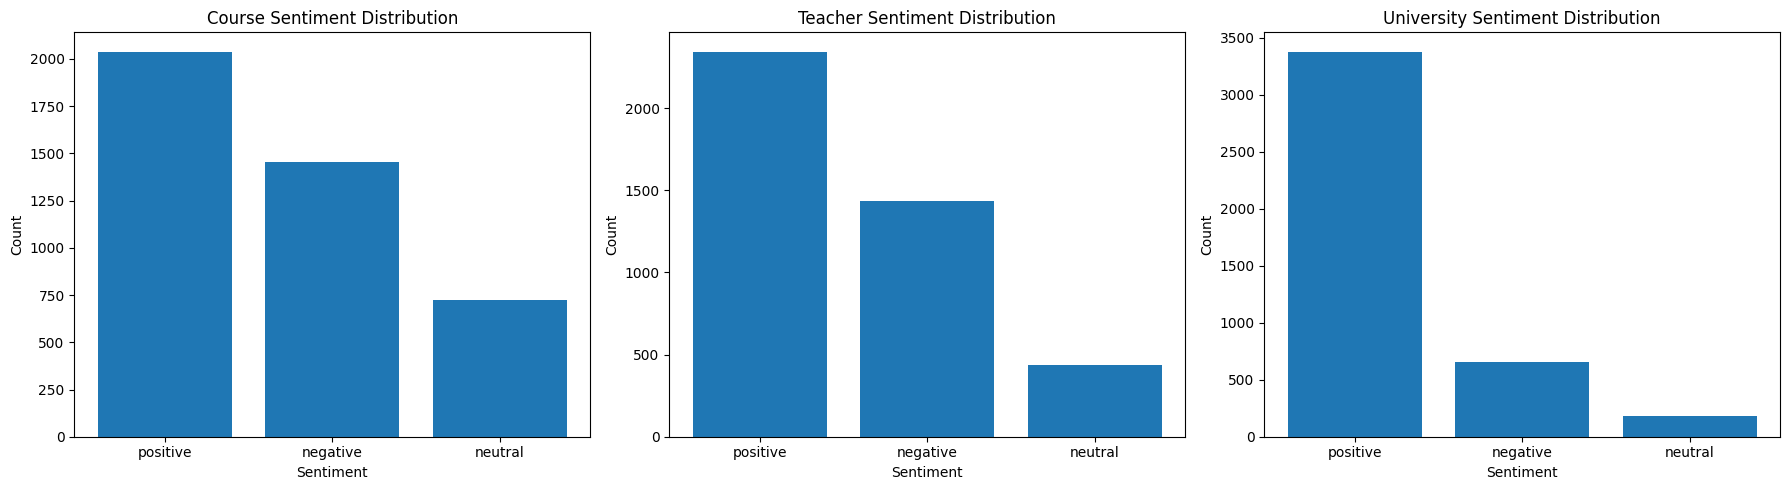

Sentiment distribution plot saved.


In [13]:
# SENTIMENT DISTRIBUTION VISUALIZATION


import matplotlib.pyplot as plt

domains = ["course", "teacher", "university"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, df) in enumerate(datasets_dict.items()):

    sentiment_counts = df["sentiment"].value_counts()

    axes[i].bar(
        sentiment_counts.index,
        sentiment_counts.values
    )

    axes[i].set_title(f"{name.capitalize()} Sentiment Distribution")

    axes[i].set_xlabel("Sentiment")
    axes[i].set_ylabel("Count")

plt.tight_layout()


plt.savefig(
    f"{PLOTS_PATH}/sentiment_distribution.png",
    bbox_inches="tight"
)

plt.show()

print("Sentiment distribution plot saved.")

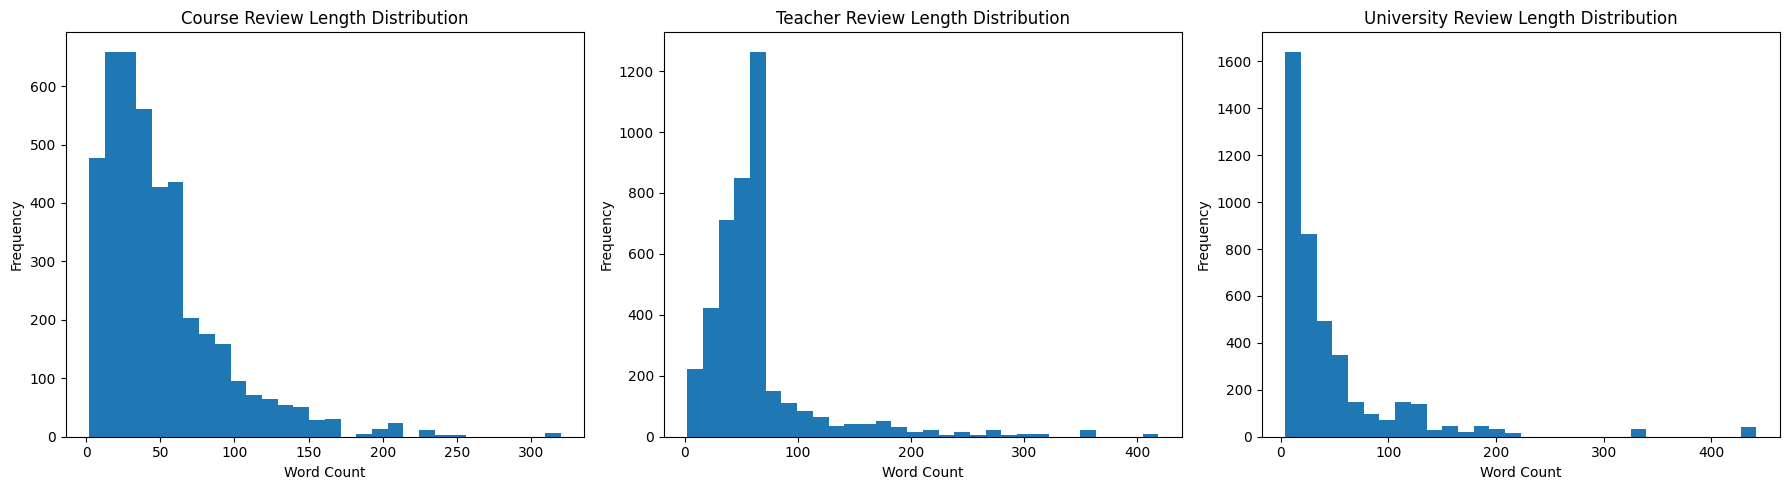

Review length distribution plot saved successfully.


In [14]:
# REVIEW LENGTH DISTRIBUTION


# Create review length column
for df in datasets_dict.values():

    df["review_length"] = df["review"].apply(
        lambda x: len(str(x).split())
    )

# Plot distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, df) in enumerate(datasets_dict.items()):

    axes[i].hist(
        df["review_length"],
        bins=30
    )

    axes[i].set_title(
        f"{name.capitalize()} Review Length Distribution"
    )

    axes[i].set_xlabel("Word Count")
    axes[i].set_ylabel("Frequency")

plt.tight_layout()


plt.savefig(
    f"{PLOTS_PATH}/review_length_distribution.png",
    bbox_inches="tight"
)

plt.show()

print("Review length distribution plot saved successfully.")

TOP 15 ASPECTS - COURSE
aspect
course         871
this course    221
class          145
assignments    142
content        138
material        68
lectures        60
midterm         52
concepts        52
final           46
textbook        44
this class      42
labs            38
topics          37
exams           37
Name: count, dtype: int64


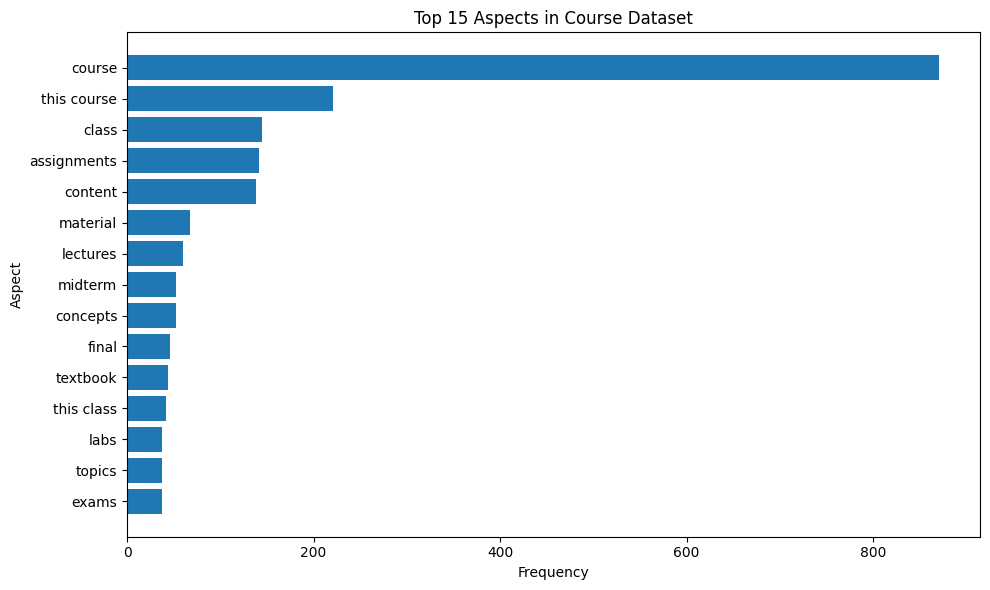

TOP 15 ASPECTS - TEACHER
aspect
class             271
professor         257
teacher           245
course            225
this class        120
prof               81
this course        79
tests              59
lectures           55
assignments        55
content            47
material           44
homework           37
textbook           37
this professor     31
Name: count, dtype: int64


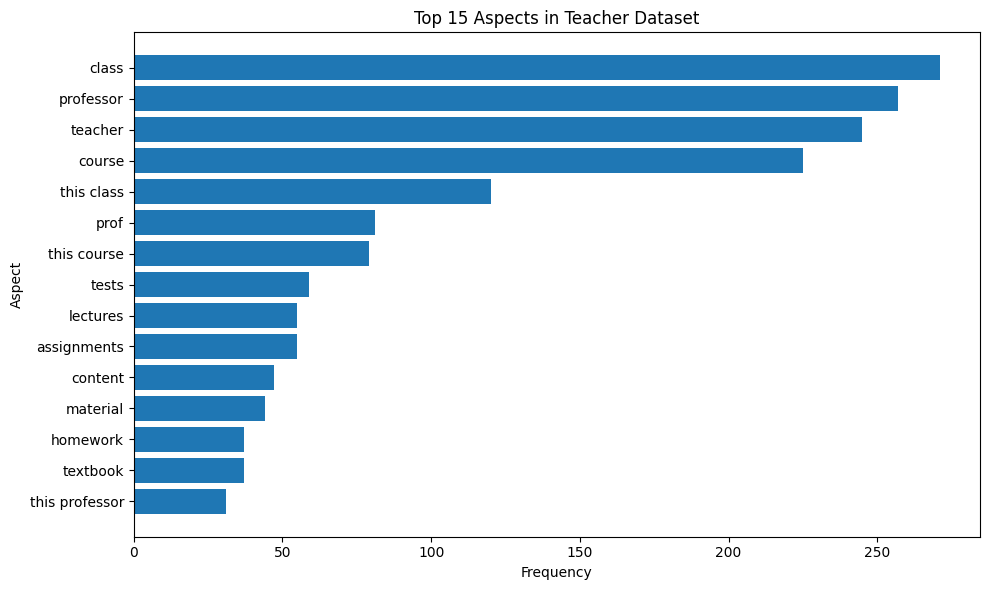

TOP 15 ASPECTS - UNIVERSITY
aspect
campus                  403
university              337
facilities              218
uni                     153
societies               127
staff                    95
lecturers                83
people                   54
course                   51
city                     45
University of Exeter     43
teachers                 42
opportunities            41
teaching                 39
environment              37
Name: count, dtype: int64


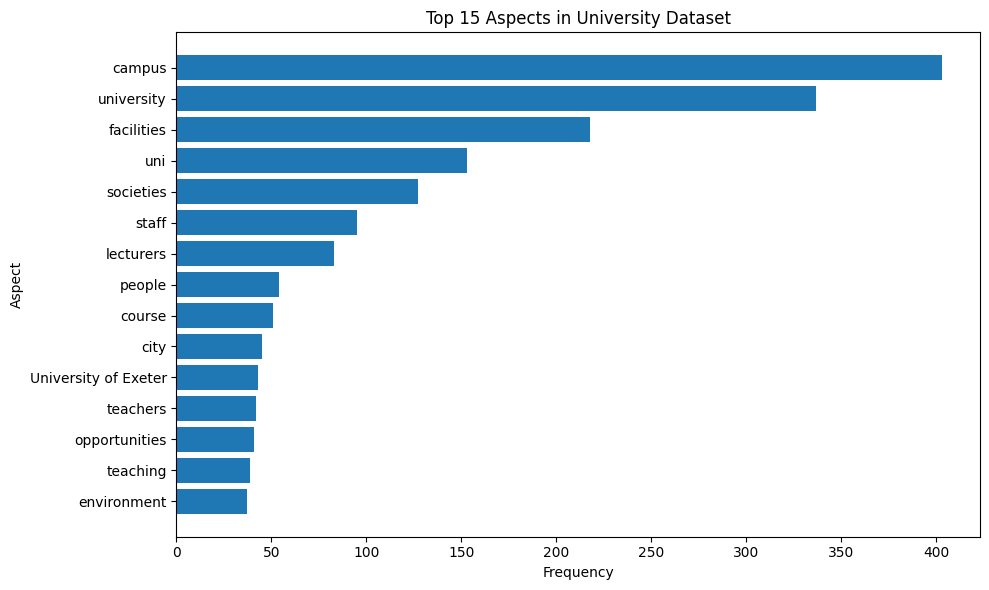

In [15]:
TOP_N = 15

for name, df in datasets_dict.items():

    print("=" * 60)
    print(f"TOP {TOP_N} ASPECTS - {name.upper()}")
    print("=" * 60)

    top_aspects = df["aspect"].value_counts().head(TOP_N)

    print(top_aspects)

    
    plt.figure(figsize=(10, 6))

    plt.barh(
        top_aspects.index[::-1],
        top_aspects.values[::-1]
    )

    plt.xlabel("Frequency")
    plt.ylabel("Aspect")

    plt.title(
        f"Top {TOP_N} Aspects in {name.capitalize()} Dataset"
    )

    plt.tight_layout()

    
    plt.savefig(
        f"{PLOTS_PATH}/{name}_top_aspects.png",
        bbox_inches="tight"
    )

    plt.show()

In [16]:
# TRAIN / TEST STRATIFICATION VERIFICATION
split_dict = {
    "course": (course_train, course_test),
    "teacher": (teacher_train, teacher_test),
    "university": (university_train, university_test)
}

for domain_name, (train_df, test_df) in split_dict.items():

    print("=" * 60)
    print(f"{domain_name.upper()} STRATIFICATION CHECK")
    print("=" * 60)

    print("\nTRAIN DISTRIBUTION (%)")
    train_dist = (
        train_df["sentiment"]
        .value_counts(normalize=True) * 100
    ).round(2)

    print(train_dist)

    print("\nTEST DISTRIBUTION (%)")
    test_dist = (
        test_df["sentiment"]
        .value_counts(normalize=True) * 100
    ).round(2)

    print(test_dist)

    print("\n")

COURSE STRATIFICATION CHECK

TRAIN DISTRIBUTION (%)
sentiment
positive    48.34
negative    34.53
neutral     17.13
Name: proportion, dtype: float64

TEST DISTRIBUTION (%)
sentiment
positive    48.34
negative    34.48
neutral     17.18
Name: proportion, dtype: float64


TEACHER STRATIFICATION CHECK

TRAIN DISTRIBUTION (%)
sentiment
positive    55.60
negative    34.05
neutral     10.34
Name: proportion, dtype: float64

TEST DISTRIBUTION (%)
sentiment
positive    55.57
negative    34.12
neutral     10.31
Name: proportion, dtype: float64


UNIVERSITY STRATIFICATION CHECK

TRAIN DISTRIBUTION (%)
sentiment
positive    80.14
negative    15.56
neutral      4.30
Name: proportion, dtype: float64

TEST DISTRIBUTION (%)
sentiment
positive    80.09
negative    15.64
neutral      4.27
Name: proportion, dtype: float64




In [17]:
# COMBINED MULTIDOMAIN DATASET ANALYSIS


print("=" * 60)
print("MULTIDOMAIN DATASET OVERVIEW")
print("=" * 60)

print("\nTotal Training Samples:")
print(len(multidomain_train_df))

print("\nDomain Distribution:")
print(multidomain_train_df["domain"].value_counts())

print("\nSentiment Distribution:")
print(multidomain_train_df["sentiment"].value_counts())

print("\nSentiment Distribution (%)")
print(
    (
        multidomain_train_df["sentiment"]
        .value_counts(normalize=True) * 100
    ).round(2)
)

print("\nUnique Aspects Across All Domains:")
print(multidomain_train_df["aspect"].nunique())

# Review length stats
multidomain_train_df["review_length"] = (
    multidomain_train_df["review"]
    .apply(lambda x: len(str(x).split()))
)

print("\nAverage Review Length:")
print(
    round(
        multidomain_train_df["review_length"].mean(),
        2
    )
)

print("\nMedian Review Length:")
print(
    round(
        multidomain_train_df["review_length"].median(),
        2
    )
)

print("\nMaximum Review Length:")
print(multidomain_train_df["review_length"].max())

print("\nMinimum Review Length:")
print(multidomain_train_df["review_length"].min())

MULTIDOMAIN DATASET OVERVIEW

Total Training Samples:
10122

Domain Distribution:
domain
course        3374
teacher       3374
university    3374
Name: count, dtype: int64

Sentiment Distribution:
sentiment
positive    6211
negative    2839
neutral     1072
Name: count, dtype: int64

Sentiment Distribution (%)
sentiment
positive    61.36
negative    28.05
neutral     10.59
Name: proportion, dtype: float64

Unique Aspects Across All Domains:
2887

Average Review Length:
54.15

Median Review Length:
42.0

Maximum Review Length:
442

Minimum Review Length:
2


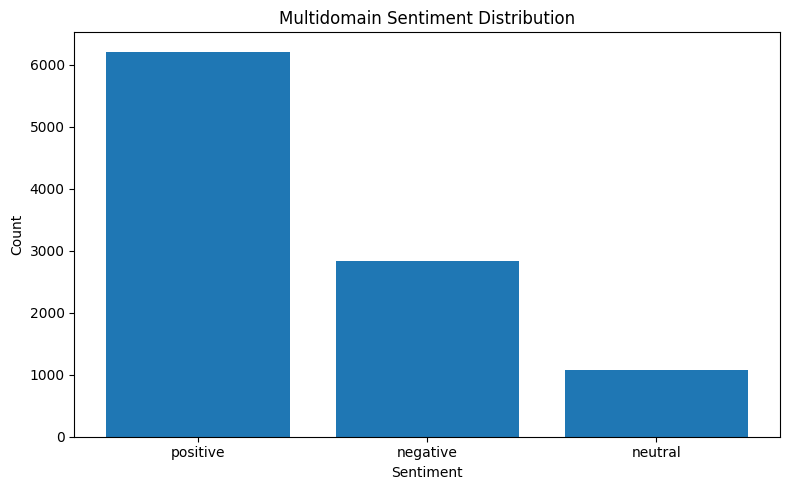

Multidomain sentiment distribution plot saved.


In [18]:
# MULTIDOMAIN SENTIMENT DISTRIBUTION


plt.figure(figsize=(8, 5))

sentiment_counts = (
    multidomain_train_df["sentiment"]
    .value_counts()
)

plt.bar(
    sentiment_counts.index,
    sentiment_counts.values
)

plt.title("Multidomain Sentiment Distribution")

plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.tight_layout()

# Save figure
plt.savefig(
    f"{PLOTS_PATH}/multidomain_sentiment_distribution.png",
    bbox_inches="tight"
)

plt.show()

print("Multidomain sentiment distribution plot saved.")

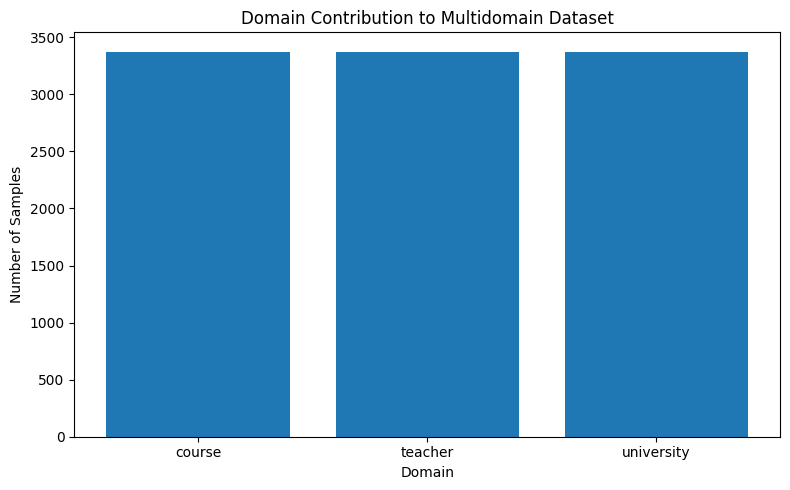

Domain contribution plot saved successfully.


In [19]:
# DOMAIN CONTRIBUTION VISUALIZATION


plt.figure(figsize=(8, 5))

domain_counts = (
    multidomain_train_df["domain"]
    .value_counts()
)

plt.bar(
    domain_counts.index,
    domain_counts.values
)

plt.title("Domain Contribution to Multidomain Dataset")

plt.xlabel("Domain")
plt.ylabel("Number of Samples")

plt.tight_layout()

# Save figure
plt.savefig(
    f"{PLOTS_PATH}/domain_contribution.png",
    bbox_inches="tight"
)

plt.show()

print("Domain contribution plot saved successfully.")

       domain  neutral_count  total_samples  neutral_percentage
0      course            723           4218               17.14
1     teacher            436           4218               10.34
2  university            181           4218                4.29


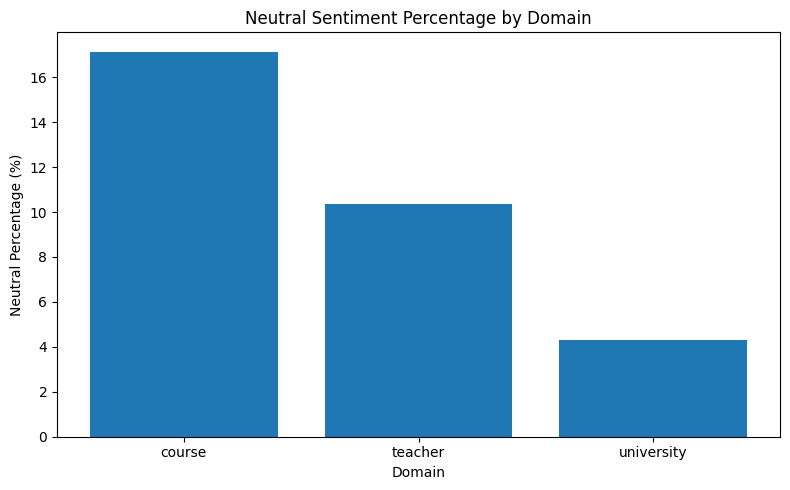

Neutral sentiment analysis plot saved.


In [20]:
# NEUTRAL SENTIMENT ANALYSIS


neutral_stats = []

for name, df in datasets_dict.items():

    total_samples = len(df)

    neutral_count = (
        df["sentiment"] == "neutral"
    ).sum()

    neutral_percentage = (
        neutral_count / total_samples
    ) * 100

    neutral_stats.append({
        "domain": name,
        "neutral_count": neutral_count,
        "total_samples": total_samples,
        "neutral_percentage": round(
            neutral_percentage,
            2
        )
    })

neutral_df = pd.DataFrame(neutral_stats)

print(neutral_df)


# VISUALIZATION


plt.figure(figsize=(8, 5))

plt.bar(
    neutral_df["domain"],
    neutral_df["neutral_percentage"]
)

plt.title("Neutral Sentiment Percentage by Domain")

plt.xlabel("Domain")
plt.ylabel("Neutral Percentage (%)")

plt.tight_layout()


plt.savefig(
    f"{PLOTS_PATH}/neutral_sentiment_analysis.png",
    bbox_inches="tight"
)

plt.show()

print("Neutral sentiment analysis plot saved.")

Tokenizer loaded successfully.
TOKEN LENGTH ANALYSIS

Average Token Length:
65.23

Median Token Length:
51.0

Maximum Token Length:
528

Minimum Token Length:
3


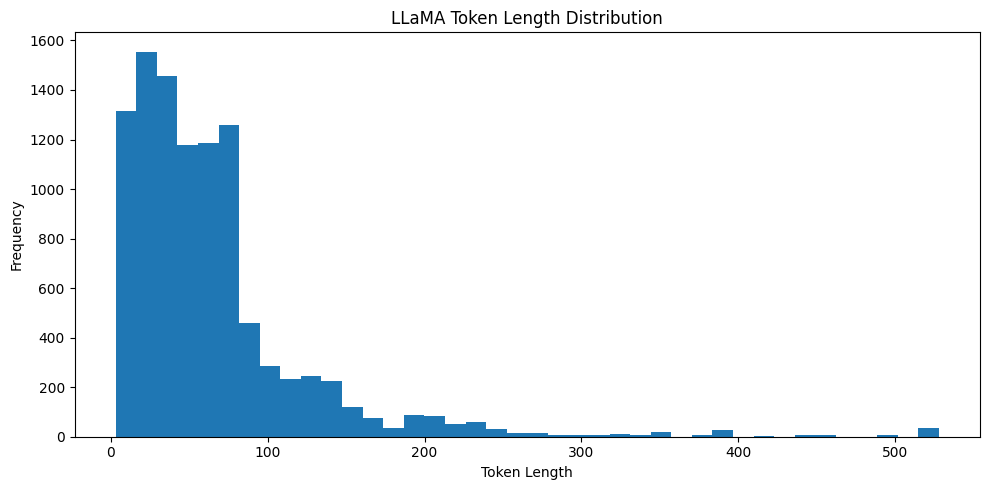

Token length analysis plot saved.


In [22]:
# TOKEN LENGTH ANALYSIS FOR LLAMA


from transformers import AutoTokenizer

MODEL_NAME = "meta-llama/Llama-3.2-3B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

tokenizer.pad_token = tokenizer.eos_token
print("Tokenizer loaded successfully.")


token_lengths = []

sample_df = multidomain_train_df.copy()

for review in sample_df["review"]:

    tokens = tokenizer.encode(
        str(review),
        truncation=False
    )

    token_lengths.append(len(tokens))

sample_df["token_length"] = token_lengths



print("=" * 60)
print("TOKEN LENGTH ANALYSIS")
print("=" * 60)

print("\nAverage Token Length:")
print(round(sample_df["token_length"].mean(), 2))

print("\nMedian Token Length:")
print(round(sample_df["token_length"].median(), 2))

print("\nMaximum Token Length:")
print(sample_df["token_length"].max())

print("\nMinimum Token Length:")
print(sample_df["token_length"].min())



plt.figure(figsize=(10, 5))

plt.hist(
    sample_df["token_length"],
    bins=40
)

plt.title("LLaMA Token Length Distribution")

plt.xlabel("Token Length")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    f"{PLOTS_PATH}/llama_token_length_distribution.png",
    bbox_inches="tight"
)

plt.show()

print("Token length analysis plot saved.")

In [23]:
# PROMPT ENGINEERING FUNCTION


def create_prompt(review, aspect, label=None):

    prompt = f"""
You are an expert aspect-based sentiment analysis classifier.

Your task is to determine the sentiment expressed towards the given aspect.

Review:
{review}

Aspect:
{aspect}

Sentiment options:
positive
negative
neutral
"""

    
    if label is not None:

        prompt += f"\nSentiment:\n{id2label[label]}"

    return prompt.strip()


# EXAMPLE PROMPT


example_prompt = create_prompt(
    review=course_df.iloc[0]["review"],
    aspect=course_df.iloc[0]["aspect"],
    label=course_df.iloc[0]["label"]
)

print(example_prompt)

You are an expert aspect-based sentiment analysis classifier.

Your task is to determine the sentiment expressed towards the given aspect.

Review:
This course was amazing. For the first time, there's no worrying about your lab partner: it's just you and the chemicals. When I took this course, it was just 4 long experiments and you organize your time accordingly throughout the semester: for students taking it in Fall 2016, you now have 7+ experiments, so I'm not sure how much the formatting's changed. It's a lot of work, but it's incredibly rewarding. I loved it.

Aspect:
course

Sentiment options:
positive
negative
neutral

Sentiment:
positive


In [24]:
train_prompts = []

for _, row in multidomain_train_df.iterrows():

    prompt = create_prompt(
        review=row["review"],
        aspect=row["aspect"],
        label=row["label"]
    )

    train_prompts.append({
        "text": prompt
    })

print("Total Training Prompts:")
print(len(train_prompts))

print("\nSample Training Prompt:\n")
print(train_prompts[0]["text"][:1000])

Total Training Prompts:
10122

Sample Training Prompt:

You are an expert aspect-based sentiment analysis classifier.

Your task is to determine the sentiment expressed towards the given aspect.

Review:
I was pleasantly surprised by this course. It seems to have been changed significantly over the past few years, and is now a better fit for iterative software development methodologies. Assignments are based on collecting and analyzing requirements and specifications for your capstone project, which can be useful. The course covers a width breadth of topics, though the final exam is almost entirely application-based.

Aspect:
the final exam

Sentiment options:
positive
negative
neutral

Sentiment:
neutral


In [25]:
train_dataset = Dataset.from_pandas(
    pd.DataFrame(train_prompts)
)

print(train_dataset)

print("\nSample Dataset Entry:\n")
print(train_dataset[0])

Dataset({
    features: ['text'],
    num_rows: 10122
})

Sample Dataset Entry:

{'text': 'You are an expert aspect-based sentiment analysis classifier.\n\nYour task is to determine the sentiment expressed towards the given aspect.\n\nReview:\nI was pleasantly surprised by this course. It seems to have been changed significantly over the past few years, and is now a better fit for iterative software development methodologies. Assignments are based on collecting and analyzing requirements and specifications for your capstone project, which can be useful. The course covers a width breadth of topics, though the final exam is almost entirely application-based.\n\nAspect:\nthe final exam\n\nSentiment options:\npositive\nnegative\nneutral\n\nSentiment:\nneutral'}


In [26]:
MAX_LENGTH = 128

print("Maximum Sequence Length:", MAX_LENGTH)

Maximum Sequence Length: 128


In [27]:
def tokenize_function(example):

    tokens = tokenizer(
        example["text"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH
    )

    tokens["labels"] = tokens["input_ids"].copy()

    return tokens

tokenized_train_dataset = train_dataset.map(
    tokenize_function,
    batched=False
)

print("\nDataset retokenized successfully.")

Map:   0%|          | 0/10122 [00:00<?, ? examples/s]


Dataset retokenized successfully.


In [28]:
# LOAD LLAMA MODEL (FULL FINETUNING)


from transformers import AutoModelForCausalLM

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="auto",
    offload_buffers=True,
    low_cpu_mem_usage=True
)

model.gradient_checkpointing_enable()

model.config.use_cache = False

model.enable_input_require_grads()

print("\nModel loaded successfully.")

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]


Model loaded successfully.


In [29]:
# DATA COLLATOR


from transformers import DataCollatorForLanguageModeling

data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False
)

print("Data collator initialized.")

Data collator initialized.


In [30]:
from transformers import TrainingArguments

training_args = TrainingArguments(

    output_dir=f"{MULTIDOMAIN_LLAMA_PATH}/training_output",

    num_train_epochs=3,

    per_device_train_batch_size=1,

    gradient_accumulation_steps=32,

    learning_rate=2e-5,

    logging_steps=20,

    save_strategy="no",

    evaluation_strategy="no",

    fp16=False,

    bf16=False,

    gradient_checkpointing=True,

    optim="paged_adamw_8bit",

    report_to="none",

    remove_unused_columns=False
)

print("Training arguments configured.")

Training arguments configured.


In [36]:
# INITIALIZE TRAINER


from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    data_collator=data_collator
)

print("Trainer initialized successfully.")

Trainer initialized successfully.


In [32]:
# GPU MEMORY CHECK


if torch.cuda.is_available():

    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

    print(
        "Allocated Memory:",
        round(
            torch.cuda.memory_allocated() / 1024**3,
            2
        ),
        "GB"
    )

    print(
        "Reserved Memory:",
        round(
            torch.cuda.memory_reserved() / 1024**3,
            2
        ),
        "GB"
    )

GPU: NVIDIA GeForce RTX 3090
Allocated Memory: 5.98 GB
Reserved Memory: 6.03 GB


In [37]:
trainer.train()

Step,Training Loss
20,1.838900
40,1.555100
60,1.403900
80,1.352000
100,1.233600
120,1.193900
140,1.112100
160,1.075200
180,1.040200
200,0.962000


TrainOutput(global_step=948, training_loss=0.6037425935771394, metrics={'train_runtime': 4063.5953, 'train_samples_per_second': 7.473, 'train_steps_per_second': 0.233, 'total_flos': 6.567131203869082e+16, 'train_loss': 0.6037425935771394, 'epoch': 2.997036158861885})

In [38]:
SAVE_PATH = f"{MULTIDOMAIN_LLAMA_PATH}/final_model"

trainer.save_model(SAVE_PATH)

tokenizer.save_pretrained(SAVE_PATH)

print("Model saved successfully.")

print("\nSaved to:")
print(SAVE_PATH)

Model saved successfully.

Saved to:
/home/jovyan/work/Dissertation/multidomain_llama/final_model


In [40]:
# LOAD SHARED TEST SETS


import pandas as pd

course_test = pd.read_csv(
    f"{SHARED_TEST_PATH}/course_test_shared.csv"
)

teacher_test = pd.read_csv(
    f"{SHARED_TEST_PATH}/teacher_test_shared.csv"
)

university_test = pd.read_csv(
    f"{SHARED_TEST_PATH}/university_test_shared.csv"
)

print("Shared test sets loaded successfully.\n")

print("Course Test Shape:")
print(course_test.shape)

print("\nTeacher Test Shape:")
print(teacher_test.shape)

print("\nUniversity Test Shape:")
print(university_test.shape)

Shared test sets loaded successfully.

Course Test Shape:
(844, 6)

Teacher Test Shape:
(844, 6)

University Test Shape:
(844, 6)


In [41]:
# LOAD SAVED MULTIDOMAIN MODEL


from transformers import AutoTokenizer, AutoModelForCausalLM

MODEL_PATH = f"{MULTIDOMAIN_LLAMA_PATH}/final_model"

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_PATH,
    torch_dtype=torch.float16,
    device_map="auto"
)

model.eval()

print("Saved multidomain model loaded successfully.")

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Some parameters are on the meta device because they were offloaded to the cpu.


Saved multidomain model loaded successfully.


In [44]:
def generate_prediction(review, aspect):

    prompt = f"""
You are an expert aspect-based sentiment analysis classifier.

Your task is to determine the sentiment expressed towards the given aspect.

Review:
{review}

Aspect:
{aspect}

Sentiment options:
positive
negative
neutral

Sentiment:
"""

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=128
    ).to(model.device)

    with torch.no_grad():

        outputs = model.generate(
            **inputs,

            max_new_tokens=5,

            do_sample=False,

            temperature=None,

            pad_token_id=tokenizer.eos_token_id
        )

    prediction = tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    )

    prediction = prediction.split("Sentiment:")[-1].strip().lower()

    if "positive" in prediction:
        return "positive"

    elif "negative" in prediction:
        return "negative"

    elif "neutral" in prediction:
        return "neutral"

    else:
        return "neutral"

print("Clean inference function created.")

Clean inference function created.


In [45]:
# TEST SINGLE PREDICTION


sample_prediction = generate_prediction(
    review=course_test.iloc[0]["review"],
    aspect=course_test.iloc[0]["aspect"]
)

print("Review:")
print(course_test.iloc[0]["review"])

print("\nAspect:")
print(course_test.iloc[0]["aspect"])

print("\nTrue Sentiment:")
print(course_test.iloc[0]["sentiment"])

print("\nPredicted Sentiment:")
print(sample_prediction)

Review:
The programming language( Scheme/ Dr. Racket) wasn't a very good program to use but the concepts behind it are the same I guess...

Aspect:
programming language

True Sentiment:
negative

Predicted Sentiment:
negative


In [46]:
from tqdm import tqdm

course_predictions = []

for _, row in tqdm(course_test.iterrows(), total=len(course_test)):

    pred = generate_prediction(
        review=row["review"],
        aspect=row["aspect"]
    )

    course_predictions.append(pred)

course_test["predicted_sentiment"] = course_predictions

print("Course predictions completed.")

course_test.head()

100%|██████████| 844/844 [50:27<00:00,  3.59s/it]

Course predictions completed.


,review,aspect,sentiment,domain,row_id,label,predicted_sentiment
0,The programming language( Scheme/ Dr. Racket) ...,programming language,negative,course,course_188,0,negative
1,This class is literally just epsilon and delta...,mobius quizzes,negative,course,course_3409,0,negative
2,Overall content heavy and quite a tricky cours...,course,negative,course,course_254,0,negative
3,Professor Sneed's class was a semi tough one. ...,Professor Sneed class,positive,course,course_1797,2,neutral
4,Despite many ppl complaining about the Mobius ...,desmos,positive,course,course_3891,2,neutral


In [47]:
course_test.to_csv(
    f"{MULTIDOMAIN_LLAMA_PATH}/course_predictions.csv",
    index=False
)

print("Course predictions saved successfully.")

Course predictions saved successfully.


In [48]:
# GENERATE TEACHER PREDICTIONS


from tqdm import tqdm

teacher_predictions = []

for _, row in tqdm(teacher_test.iterrows(), total=len(teacher_test)):

    pred = generate_prediction(
        review=row["review"],
        aspect=row["aspect"]
    )

    teacher_predictions.append(pred)

teacher_test["predicted_sentiment"] = teacher_predictions

print("Teacher predictions completed.")

teacher_test.head()

100%|██████████| 844/844 [59:13<00:00,  4.21s/it]

Teacher predictions completed.


,review,aspect,sentiment,domain,row_id,label,predicted_sentiment
0,"This class was harder than I expected, especia...",This class,negative,teacher,teacher_3717,0,negative
1,"Good teacher, very helpful. He is very funny a...",teacher,positive,teacher,teacher_671,2,positive
2,Ms. Young is a great professor. I was computer...,this class,positive,teacher,teacher_2314,2,neutral
3,TURN YOUR WORK IN ON TIME!!!! In only the seco...,getting an A,neutral,teacher,teacher_1051,1,neutral
4,Truly a sweet professor. Very understanding an...,open class discussions,negative,teacher,teacher_1118,0,neutral


In [49]:
teacher_test.to_csv(
    f"{MULTIDOMAIN_LLAMA_PATH}/teacher_predictions.csv",
    index=False
)

print("Teacher predictions saved successfully.")

Teacher predictions saved successfully.


In [52]:
 # UNIVERSITY PREDICTIONS

from tqdm import tqdm

university_predictions = []

for _, row in tqdm(university_test.iterrows(), total=len(university_test)):

    pred = generate_prediction(
        review=row["review"],
        aspect=row["aspect"]
    )

    university_predictions.append(pred)

university_test["predicted_sentiment"] = university_predictions

print("University predictions completed.")

university_test.head()

100%|██████████| 844/844 [1:07:15<00:00,  4.78s/it]

University predictions completed.


,review,aspect,sentiment,domain,row_id,label,predicted_sentiment
0,Exeter University was my first choice and I do...,community,positive,university,university_1004,2,positive
1,"Nice university to study in, all the teachers ...",university,positive,university,university_3270,2,positive
2,I love the options for my course and the uni i...,options for my course,positive,university,university_1143,2,positive
3,It’s difficult for me to rate the aspects of t...,students union,neutral,university,university_2061,1,positive
4,Brilliant university. Home away from home.,university,positive,university,university_3278,2,positive


In [53]:
university_test.to_csv(
    f"{MULTIDOMAIN_LLAMA_PATH}/university_predictions.csv",
    index=False
)

print("University predictions saved successfully.")

University predictions saved successfully.


In [54]:
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report
)

print("Evaluation metrics imported.")

Evaluation metrics imported.


In [55]:
def evaluate_predictions(df, domain_name):

    y_true = df["sentiment"]

    y_pred = df["predicted_sentiment"]

    accuracy = accuracy_score(y_true, y_pred)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="weighted"
    )

    print("=" * 60)
    print(f"{domain_name.upper()} EVALUATION")
    print("=" * 60)

    print(f"\nAccuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1-Score  : {f1:.4f}")

    print("\nClassification Report:\n")

    print(
        classification_report(
            y_true,
            y_pred
        )
    )

    return {
        "domain": domain_name,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

print("Evaluation function created.")

Evaluation function created.


In [56]:
course_results = evaluate_predictions(
    course_test,
    "course"
)

COURSE EVALUATION

Accuracy  : 0.5486
Precision : 0.7653
Recall    : 0.5486
F1-Score  : 0.5830

Classification Report:

              precision    recall  f1-score   support

    negative       0.84      0.70      0.77       291
     neutral       0.24      0.72      0.37       145
    positive       0.89      0.38      0.53       408

    accuracy                           0.55       844
   macro avg       0.66      0.60      0.55       844
weighted avg       0.77      0.55      0.58       844



In [57]:
teacher_results = evaluate_predictions(
    teacher_test,
    "teacher"
)

TEACHER EVALUATION

Accuracy  : 0.5818
Precision : 0.8405
Recall    : 0.5818
F1-Score  : 0.6541

Classification Report:

              precision    recall  f1-score   support

    negative       0.88      0.66      0.75       288
     neutral       0.16      0.68      0.26        87
    positive       0.95      0.51      0.67       469

    accuracy                           0.58       844
   macro avg       0.66      0.62      0.56       844
weighted avg       0.84      0.58      0.65       844



In [58]:
university_results = evaluate_predictions(
    university_test,
    "university"
)

UNIVERSITY EVALUATION

Accuracy  : 0.8081
Precision : 0.9467
Recall    : 0.8081
F1-Score  : 0.8567

Classification Report:

              precision    recall  f1-score   support

    negative       0.93      0.59      0.72       132
     neutral       0.17      0.89      0.29        36
    positive       0.99      0.85      0.91       676

    accuracy                           0.81       844
   macro avg       0.70      0.78      0.64       844
weighted avg       0.95      0.81      0.86       844



In [59]:
results_df = pd.DataFrame([
    course_results,
    teacher_results,
    university_results
])

results_df = results_df.round(4)

print(results_df)

       domain  accuracy  precision  recall      f1
0      course    0.5486     0.7653  0.5486  0.5830
1     teacher    0.5818     0.8405  0.5818  0.6541
2  university    0.8081     0.9467  0.8081  0.8567


In [60]:
results_df.to_csv(
    f"{METRICS_PATH}/multidomain_llama_results.csv",
    index=False
)

print("Results table saved successfully.")

Results table saved successfully.


In [61]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

print("Confusion matrix libraries imported.")

Confusion matrix libraries imported.


In [62]:
def plot_confusion_matrix(df, domain_name):

    labels = ["negative", "neutral", "positive"]

    cm = confusion_matrix(
        df["sentiment"],
        df["predicted_sentiment"],
        labels=labels
    )

    plt.figure(figsize=(6, 5))

    plt.imshow(cm)

    plt.title(f"{domain_name.upper()} Confusion Matrix")

    plt.colorbar()

    tick_marks = np.arange(len(labels))

    plt.xticks(tick_marks, labels)

    plt.yticks(tick_marks, labels)

    plt.xlabel("Predicted Label")

    plt.ylabel("True Label")

    for i in range(len(labels)):
        for j in range(len(labels)):

            plt.text(
                j,
                i,
                cm[i, j],
                ha="center",
                va="center"
            )

    plt.tight_layout()

    plt.show()

print("Confusion matrix function created.")

Confusion matrix function created.


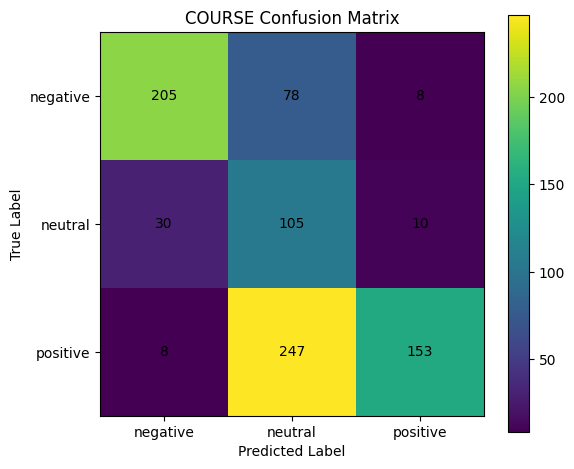

In [63]:
plot_confusion_matrix(course_test, "course")

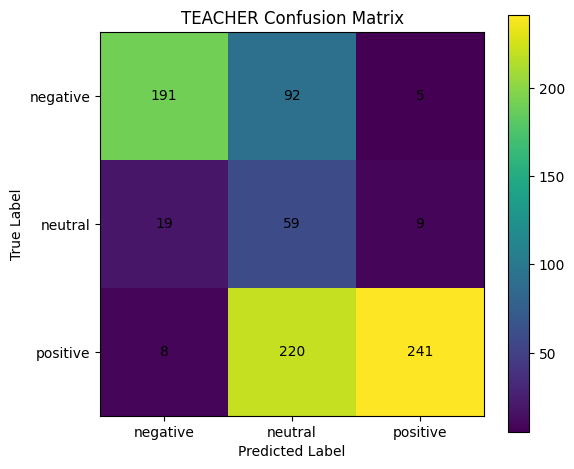

In [64]:
plot_confusion_matrix(
    teacher_test,
    "teacher"
)

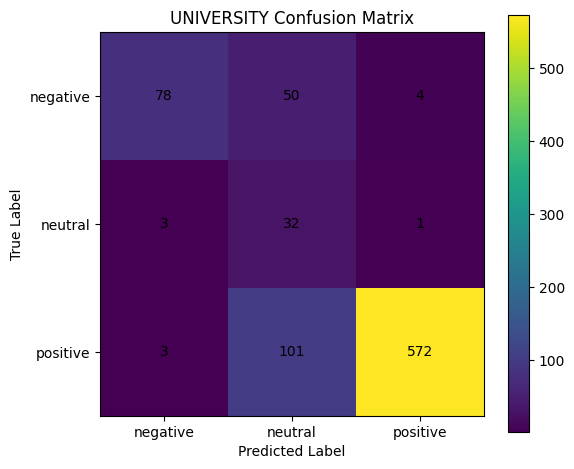

In [65]:
plot_confusion_matrix(
    university_test,
    "university"
)

Key Findings
Course Domain
Strong confusion between:
positive ↔ neutral
Model is conservative when sentiment is mildly positive.
Teacher Domain
Same pattern persists:
many positive samples predicted as neutral (220)
Indicates uncertainty in nuanced teaching-related opinions.
University Domain
Best-performing domain overall.
Positive sentiment classified very well (572 correct).
Makes sense because university dataset is highly positive-skewed.

However:

even here,
many positives still drift into neutral (101).
Important Cross-Domain Insight

Across ALL domains:

neutral recall is high,
neutral precision is low,
showing systematic neutral overprediction.

This becomes a strong comparative discussion point against:

ModernBERT,
and cross-domain LLaMA.

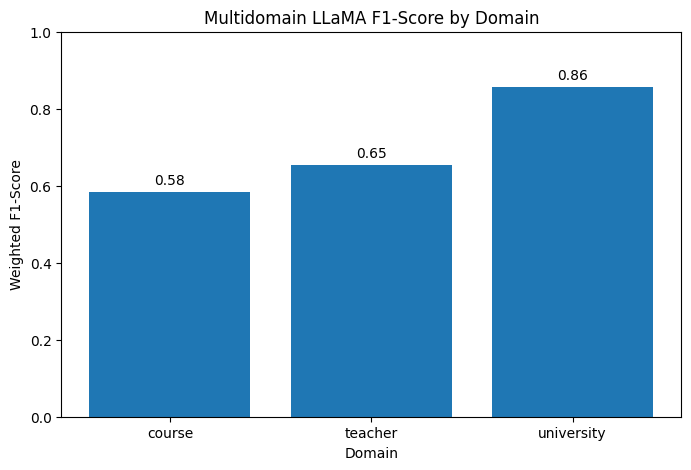

In [66]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    results_df["domain"],
    results_df["f1"]
)

plt.title("Multidomain LLaMA F1-Score by Domain")

plt.xlabel("Domain")

plt.ylabel("Weighted F1-Score")

plt.ylim(0, 1)

for i, value in enumerate(results_df["f1"]):

    plt.text(
        i,
        value + 0.02,
        f"{value:.2f}",
        ha="center"
    )

plt.show()

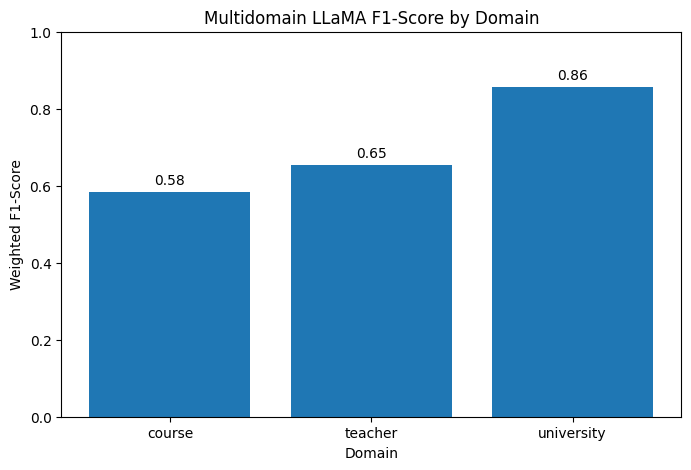

F1-score plot saved successfully.


In [67]:
plt.figure(figsize=(8, 5))

plt.bar(
    results_df["domain"],
    results_df["f1"]
)

plt.title("Multidomain LLaMA F1-Score by Domain")

plt.xlabel("Domain")

plt.ylabel("Weighted F1-Score")

plt.ylim(0, 1)

for i, value in enumerate(results_df["f1"]):

    plt.text(
        i,
        value + 0.02,
        f"{value:.2f}",
        ha="center"
    )

plt.savefig(
    f"{PLOTS_PATH}/multidomain_llama_f1_scores.png",
    bbox_inches="tight"
)

plt.show()

print("F1-score plot saved successfully.")

In [68]:
def save_confusion_matrix(df, domain_name):

    labels = ["negative", "neutral", "positive"]

    cm = confusion_matrix(
        df["sentiment"],
        df["predicted_sentiment"],
        labels=labels
    )

    plt.figure(figsize=(6, 5))

    plt.imshow(cm)

    plt.title(f"{domain_name.upper()} Confusion Matrix")

    plt.colorbar()

    tick_marks = np.arange(len(labels))

    plt.xticks(tick_marks, labels)

    plt.yticks(tick_marks, labels)

    plt.xlabel("Predicted Label")

    plt.ylabel("True Label")

    for i in range(len(labels)):
        for j in range(len(labels)):

            plt.text(
                j,
                i,
                cm[i, j],
                ha="center",
                va="center"
            )

    plt.tight_layout()

    plt.savefig(
        f"{PLOTS_PATH}/{domain_name}_confusion_matrix.png",
        bbox_inches="tight"
    )

    plt.close()

    print(f"{domain_name} confusion matrix saved.")




save_confusion_matrix(course_test, "course")

save_confusion_matrix(teacher_test, "teacher")

save_confusion_matrix(university_test, "university")

course confusion matrix saved.
teacher confusion matrix saved.
university confusion matrix saved.


In [69]:
cross_course = pd.read_csv(
    "/home/jovyan/work/teacher_university_to_course_best_predictions.csv"
)

print("Cross-domain course predictions loaded.")

print("\nShape:")
print(cross_course.shape)

cross_course.head()

Cross-domain course predictions loaded.

Shape:
(844, 10)


,review,aspect,sentiment,domain,row_id,input_text,label,text,true_sentiment,predicted_sentiment
0,The programming language( Scheme/ Dr. Racket) ...,programming language,negative,course,course_188,[DOMAIN] course [ASPECT] programming language ...,0,<s>[INST] You are an expert in aspect-based se...,negative,negative
1,This class is literally just epsilon and delta...,mobius quizzes,negative,course,course_3409,[DOMAIN] course [ASPECT] mobius quizzes [TEXT]...,0,<s>[INST] You are an expert in aspect-based se...,negative,negative
2,Overall content heavy and quite a tricky cours...,course,negative,course,course_254,[DOMAIN] course [ASPECT] course [TEXT] Overall...,0,<s>[INST] You are an expert in aspect-based se...,negative,positive
3,Professor Sneed's class was a semi tough one. ...,Professor Sneed class,positive,course,course_1797,[DOMAIN] course [ASPECT] Professor Sneed class...,2,<s>[INST] You are an expert in aspect-based se...,positive,neutral
4,Despite many ppl complaining about the Mobius ...,desmos,positive,course,course_3891,[DOMAIN] course [ASPECT] desmos [TEXT] Despite...,2,<s>[INST] You are an expert in aspect-based se...,positive,positive


In [71]:
cross_teacher = pd.read_csv(
    "/home/jovyan/work/course_university_to_teacher_best_predictions (1).csv"
)

print("Cross-domain teacher predictions loaded.")

print("\nShape:")
print(cross_teacher.shape)

cross_teacher.head()

Cross-domain teacher predictions loaded.

Shape:
(844, 10)


,review,aspect,sentiment,domain,row_id,input_text,label,text,true_sentiment,predicted_sentiment
0,"This class was harder than I expected, especia...",This class,negative,teacher,teacher_3717,[DOMAIN] teacher [ASPECT] This class [TEXT] Th...,0,<s>[INST] You are an expert in aspect-based se...,negative,negative
1,"Good teacher, very helpful. He is very funny a...",teacher,positive,teacher,teacher_671,[DOMAIN] teacher [ASPECT] teacher [TEXT] Good ...,2,<s>[INST] You are an expert in aspect-based se...,positive,positive
2,Ms. Young is a great professor. I was computer...,this class,positive,teacher,teacher_2314,[DOMAIN] teacher [ASPECT] this class [TEXT] Ms...,2,<s>[INST] You are an expert in aspect-based se...,positive,positive
3,TURN YOUR WORK IN ON TIME!!!! In only the seco...,getting an A,neutral,teacher,teacher_1051,[DOMAIN] teacher [ASPECT] getting an A [TEXT] ...,1,<s>[INST] You are an expert in aspect-based se...,neutral,positive
4,Truly a sweet professor. Very understanding an...,open class discussions,negative,teacher,teacher_1118,[DOMAIN] teacher [ASPECT] open class discussio...,0,<s>[INST] You are an expert in aspect-based se...,negative,negative


In [73]:
cross_university = pd.read_csv(
    "/home/jovyan/work/course_teacher_to_university_best_predictions (1).csv"
)

print("Cross-domain university predictions loaded.")

print("\nShape:")
print(cross_university.shape)

cross_university.head()

Cross-domain university predictions loaded.

Shape:
(844, 10)


,review,aspect,sentiment,domain,row_id,input_text,label,text,true_sentiment,predicted_sentiment
0,Exeter University was my first choice and I do...,community,positive,university,university_1004,[DOMAIN] university [ASPECT] community [TEXT] ...,2,<s>[INST] You are an expert in aspect-based se...,positive,positive
1,"Nice university to study in, all the teachers ...",university,positive,university,university_3270,[DOMAIN] university [ASPECT] university [TEXT]...,2,<s>[INST] You are an expert in aspect-based se...,positive,positive
2,I love the options for my course and the uni i...,options for my course,positive,university,university_1143,[DOMAIN] university [ASPECT] options for my co...,2,<s>[INST] You are an expert in aspect-based se...,positive,positive
3,It’s difficult for me to rate the aspects of t...,students union,neutral,university,university_2061,[DOMAIN] university [ASPECT] students union [T...,1,<s>[INST] You are an expert in aspect-based se...,neutral,neutral
4,Brilliant university. Home away from home.,university,positive,university,university_3278,[DOMAIN] university [ASPECT] university [TEXT]...,2,<s>[INST] You are an expert in aspect-based se...,positive,positive


In [74]:
course_comparison = pd.merge(

    course_test[
        [
            "row_id",
            "review",
            "aspect",
            "sentiment",
            "predicted_sentiment"
        ]
    ],

    cross_course[
        [
            "row_id",
            "predicted_sentiment"
        ]
    ],

    on="row_id",

    suffixes=(
        "_multidomain",
        "_crossdomain"
    )
)

print("Course comparison created.")

print("\nShape:")
print(course_comparison.shape)

course_comparison.head()

Course comparison created.

Shape:
(844, 6)


,row_id,review,aspect,sentiment,predicted_sentiment_multidomain,predicted_sentiment_crossdomain
0,course_188,The programming language( Scheme/ Dr. Racket) ...,programming language,negative,negative,negative
1,course_3409,This class is literally just epsilon and delta...,mobius quizzes,negative,negative,negative
2,course_254,Overall content heavy and quite a tricky cours...,course,negative,negative,positive
3,course_1797,Professor Sneed's class was a semi tough one. ...,Professor Sneed class,positive,neutral,neutral
4,course_3891,Despite many ppl complaining about the Mobius ...,desmos,positive,neutral,positive


In [75]:
teacher_comparison = pd.merge(

    teacher_test[
        [
            "row_id",
            "review",
            "aspect",
            "sentiment",
            "predicted_sentiment"
        ]
    ],

    cross_teacher[
        [
            "row_id",
            "predicted_sentiment"
        ]
    ],

    on="row_id",

    suffixes=(
        "_multidomain",
        "_crossdomain"
    )
)

print("Teacher comparison created.")

print("\nShape:")
print(teacher_comparison.shape)

teacher_comparison.head()

Teacher comparison created.

Shape:
(844, 6)


,row_id,review,aspect,sentiment,predicted_sentiment_multidomain,predicted_sentiment_crossdomain
0,teacher_3717,"This class was harder than I expected, especia...",This class,negative,negative,negative
1,teacher_671,"Good teacher, very helpful. He is very funny a...",teacher,positive,positive,positive
2,teacher_2314,Ms. Young is a great professor. I was computer...,this class,positive,neutral,positive
3,teacher_1051,TURN YOUR WORK IN ON TIME!!!! In only the seco...,getting an A,neutral,neutral,positive
4,teacher_1118,Truly a sweet professor. Very understanding an...,open class discussions,negative,neutral,negative


In [76]:
university_comparison = pd.merge(

    university_test[
        [
            "row_id",
            "review",
            "aspect",
            "sentiment",
            "predicted_sentiment"
        ]
    ],

    cross_university[
        [
            "row_id",
            "predicted_sentiment"
        ]
    ],

    on="row_id",

    suffixes=(
        "_multidomain",
        "_crossdomain"
    )
)

print("University comparison created.")

print("\nShape:")
print(university_comparison.shape)

university_comparison.head()

University comparison created.

Shape:
(844, 6)


,row_id,review,aspect,sentiment,predicted_sentiment_multidomain,predicted_sentiment_crossdomain
0,university_1004,Exeter University was my first choice and I do...,community,positive,positive,positive
1,university_3270,"Nice university to study in, all the teachers ...",university,positive,positive,positive
2,university_1143,I love the options for my course and the uni i...,options for my course,positive,positive,positive
3,university_2061,It’s difficult for me to rate the aspects of t...,students union,neutral,positive,neutral
4,university_3278,Brilliant university. Home away from home.,university,positive,positive,positive


In [77]:
course_disagreements = course_comparison[

    course_comparison["predicted_sentiment_multidomain"]
    !=
    course_comparison["predicted_sentiment_crossdomain"]

]

print("Course disagreements:")

print(len(course_disagreements))

course_disagreements.head(10)

Course disagreements:
427


,row_id,review,aspect,sentiment,predicted_sentiment_multidomain,predicted_sentiment_crossdomain
2,course_254,Overall content heavy and quite a tricky cours...,course,negative,negative,positive
4,course_3891,Despite many ppl complaining about the Mobius ...,desmos,positive,neutral,positive
6,course_275,This course is broken down into 3 distinct sec...,exam,positive,neutral,positive
8,course_3741,"I know a lot of people hated this course, but ...",The term tests,positive,neutral,positive
9,course_3775,Probably my favourite course at UW. The conten...,breakdown of the lectures,positive,neutral,positive
10,course_3868,Easiest course I've ever taken. No need to go ...,high 90,positive,neutral,positive
11,course_2180,Great course! It's definitely my favourite cla...,get a good grade,positive,neutral,positive
13,course_1125,Group work was actually ok( i normally hate gr...,tests,positive,neutral,negative
16,course_3422,The assignments were really interesting becaus...,assignments,positive,neutral,positive
20,course_3751,This course honestly kinda sucked. I took it o...,Asian movie reviews,positive,positive,negative


In [78]:
teacher_disagreements = teacher_comparison[

    teacher_comparison["predicted_sentiment_multidomain"]
    !=
    teacher_comparison["predicted_sentiment_crossdomain"]

]

print("Teacher disagreements:")

print(len(teacher_disagreements))

Teacher disagreements:
348


In [79]:
university_disagreements = university_comparison[

    university_comparison["predicted_sentiment_multidomain"]
    !=
    university_comparison["predicted_sentiment_crossdomain"]

]

print("University disagreements:")

print(len(university_disagreements))

University disagreements:
196


In [80]:
disagreement_df = pd.DataFrame({

    "domain": [
        "course",
        "teacher",
        "university"
    ],

    "total_samples": [
        len(course_comparison),
        len(teacher_comparison),
        len(university_comparison)
    ],

    "disagreements": [
        len(course_disagreements),
        len(teacher_disagreements),
        len(university_disagreements)
    ]
})

disagreement_df["disagreement_percentage"] = (
    disagreement_df["disagreements"]
    /
    disagreement_df["total_samples"]
) * 100

disagreement_df = disagreement_df.round(2)

print(disagreement_df)

       domain  total_samples  disagreements  disagreement_percentage
0      course            844            427                    50.59
1     teacher            844            348                    41.23
2  university            844            196                    23.22


In [81]:
disagreement_df.to_csv(
    f"{DISAGREEMENT_ANALYSIS_PATH}/llama_disagreement_summary.csv",
    index=False
)

print("Disagreement summary saved successfully.")

Disagreement summary saved successfully.


In [82]:
course_multi_correct = course_comparison[

    (
        course_comparison["predicted_sentiment_multidomain"]
        ==
        course_comparison["sentiment"]
    )

    &

    (
        course_comparison["predicted_sentiment_crossdomain"]
        !=
        course_comparison["sentiment"]
    )
]

print("Cases where MULTIDOMAIN was correct and CROSSDOMAIN was wrong:\n")

print("Total Cases:")
print(len(course_multi_correct))

course_multi_correct.head(10)

Cases where MULTIDOMAIN was correct and CROSSDOMAIN was wrong:

Total Cases:
108


,row_id,review,aspect,sentiment,predicted_sentiment_multidomain,predicted_sentiment_crossdomain
2,course_254,Overall content heavy and quite a tricky cours...,course,negative,negative,positive
20,course_3751,This course honestly kinda sucked. I took it o...,Asian movie reviews,positive,positive,negative
29,course_169,"Very birdy course, you learn how to communicat...",course,positive,positive,negative
30,course_2118,wuck fork term report,term report,negative,negative,positive
38,course_3765,Very challenging but useful information. You h...,optional project,positive,positive,neutral
47,course_487,"Not too heavy and if you like digital imaging,...",this course,neutral,neutral,positive
48,course_1861,Took because it was right after other course. ...,content,negative,negative,neutral
51,course_3613,Study hard for Math 135,Math 135,negative,negative,positive
62,course_3806,"For the audit portion, don't go to class; you ...",audit portion,neutral,neutral,negative
70,course_3070,"If you do poorly in this course, you're probab...",this course,neutral,neutral,negative


In [83]:
course_cross_correct = course_comparison[

    (
        course_comparison["predicted_sentiment_crossdomain"]
        ==
        course_comparison["sentiment"]
    )

    &

    (
        course_comparison["predicted_sentiment_multidomain"]
        !=
        course_comparison["sentiment"]
    )
]

print("Cases where CROSSDOMAIN was correct and MULTIDOMAIN was wrong:\n")

print("Total Cases:")
print(len(course_cross_correct))

course_cross_correct.head(10)

Cases where CROSSDOMAIN was correct and MULTIDOMAIN was wrong:

Total Cases:
271


,row_id,review,aspect,sentiment,predicted_sentiment_multidomain,predicted_sentiment_crossdomain
4,course_3891,Despite many ppl complaining about the Mobius ...,desmos,positive,neutral,positive
6,course_275,This course is broken down into 3 distinct sec...,exam,positive,neutral,positive
8,course_3741,"I know a lot of people hated this course, but ...",The term tests,positive,neutral,positive
9,course_3775,Probably my favourite course at UW. The conten...,breakdown of the lectures,positive,neutral,positive
10,course_3868,Easiest course I've ever taken. No need to go ...,high 90,positive,neutral,positive
11,course_2180,Great course! It's definitely my favourite cla...,get a good grade,positive,neutral,positive
16,course_3422,The assignments were really interesting becaus...,assignments,positive,neutral,positive
25,course_2961,really fun course. the material was enjoyable,material,positive,neutral,positive
26,course_3559,Great course on( single-input single-output) f...,Course notes,positive,neutral,positive
37,course_39,Recommend anyone new to programming to take a ...,course,negative,neutral,negative


In [84]:
course_multi_correct.to_csv(
    f"{ERROR_ANALYSIS_PATH}/course_multidomain_correct.csv",
    index=False
)

course_cross_correct.to_csv(
    f"{ERROR_ANALYSIS_PATH}/course_crossdomain_correct.csv",
    index=False
)

print("Qualitative disagreement examples saved.")

Qualitative disagreement examples saved.


In [85]:
comparison_df = pd.DataFrame({

    "domain": [
        "course",
        "teacher",
        "university"
    ],

    "multidomain_f1": [
        course_results["f1"],
        teacher_results["f1"],
        university_results["f1"]
    ]
})

print(comparison_df)

       domain  multidomain_f1
0      course        0.582951
1     teacher        0.654114
2  university        0.856692


In [86]:
from sklearn.metrics import precision_recall_fscore_support

def compute_weighted_f1(df):

    _, _, f1, _ = precision_recall_fscore_support(
        df["sentiment"],
        df["predicted_sentiment"],
        average="weighted"
    )

    return f1

cross_course_f1 = compute_weighted_f1(cross_course)

cross_teacher_f1 = compute_weighted_f1(cross_teacher)

cross_university_f1 = compute_weighted_f1(cross_university)

print("Cross-domain F1 Scores:\n")

print("Course     :", round(cross_course_f1, 4))
print("Teacher    :", round(cross_teacher_f1, 4))
print("University :", round(cross_university_f1, 4))

Cross-domain F1 Scores:

Course     : 0.7329
Teacher    : 0.8465
University : 0.9338


In [87]:
comparison_df["crossdomain_f1"] = [

    cross_course_f1,
    cross_teacher_f1,
    cross_university_f1
]

comparison_df["f1_difference"] = (

    comparison_df["multidomain_f1"]
    -
    comparison_df["crossdomain_f1"]

)

comparison_df = comparison_df.round(4)

print(comparison_df)

       domain  multidomain_f1  crossdomain_f1  f1_difference
0      course          0.5830          0.7329        -0.1500
1     teacher          0.6541          0.8465        -0.1924
2  university          0.8567          0.9338        -0.0771


In [88]:
comparison_df.to_csv(
    f"{METRICS_PATH}/llama_crossdomain_vs_multidomain.csv",
    index=False
)

print("Final comparison table saved successfully.")

Final comparison table saved successfully.


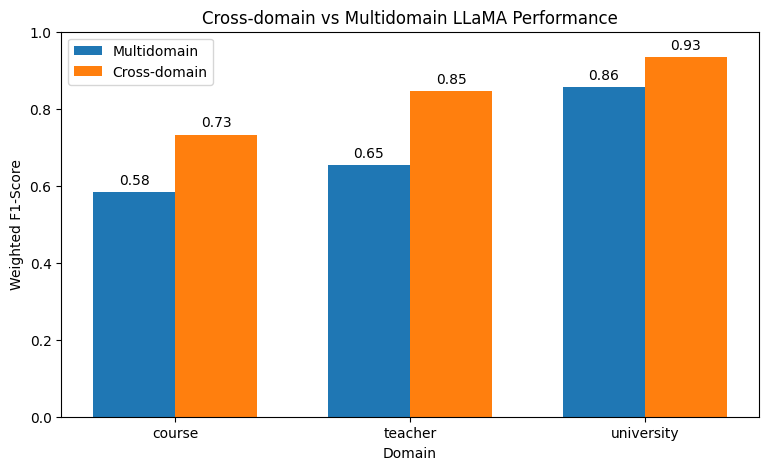

Final comparison plot saved successfully.


In [89]:
import matplotlib.pyplot as plt
import numpy as np

domains = comparison_df["domain"]

x = np.arange(len(domains))

width = 0.35

plt.figure(figsize=(9, 5))

plt.bar(
    x - width/2,
    comparison_df["multidomain_f1"],
    width,
    label="Multidomain"
)

plt.bar(
    x + width/2,
    comparison_df["crossdomain_f1"],
    width,
    label="Cross-domain"
)

plt.xticks(
    x,
    domains
)

plt.ylabel("Weighted F1-Score")

plt.xlabel("Domain")

plt.title(
    "Cross-domain vs Multidomain LLaMA Performance"
)

plt.ylim(0, 1)

plt.legend()

for i, value in enumerate(comparison_df["multidomain_f1"]):

    plt.text(
        i - width/2,
        value + 0.02,
        f"{value:.2f}",
        ha="center"
    )

for i, value in enumerate(comparison_df["crossdomain_f1"]):

    plt.text(
        i + width/2,
        value + 0.02,
        f"{value:.2f}",
        ha="center"
    )

plt.savefig(
    f"{PLOTS_PATH}/llama_crossdomain_vs_multidomain.png",
    bbox_inches="tight"
)

plt.show()

print("Final comparison plot saved successfully.")

In [90]:
course_comparison.to_csv(
    f"{DISAGREEMENT_ANALYSIS_PATH}/course_comparison.csv",
    index=False
)

teacher_comparison.to_csv(
    f"{DISAGREEMENT_ANALYSIS_PATH}/teacher_comparison.csv",
    index=False
)

university_comparison.to_csv(
    f"{DISAGREEMENT_ANALYSIS_PATH}/university_comparison.csv",
    index=False
)

print("Comparison datasets saved successfully.")

Comparison datasets saved successfully.


In [91]:
print("=" * 60)
print("MULTIDOMAIN LLAMA PIPELINE COMPLETED")
print("=" * 60)

print("\nGenerated Artifacts:")

print("\nPrediction CSVs:")
print("- course_predictions.csv")
print("- teacher_predictions.csv")
print("- university_predictions.csv")

print("\nMetrics:")
print("- multidomain_llama_results.csv")
print("- llama_crossdomain_vs_multidomain.csv")

print("\nPlots:")
print("- multidomain_llama_f1_scores.png")
print("- llama_crossdomain_vs_multidomain.png")
print("- course_confusion_matrix.png")
print("- teacher_confusion_matrix.png")
print("- university_confusion_matrix.png")

print("\nDisagreement Analysis:")
print("- course_comparison.csv")
print("- teacher_comparison.csv")
print("- university_comparison.csv")
print("- llama_disagreement_summary.csv")

print("\nError Analysis:")
print("- course_multidomain_correct.csv")
print("- course_crossdomain_correct.csv")

print("\nModel:")
print("- final_model/")

MULTIDOMAIN LLAMA PIPELINE COMPLETED

Generated Artifacts:

Prediction CSVs:
- course_predictions.csv
- teacher_predictions.csv
- university_predictions.csv

Metrics:
- multidomain_llama_results.csv
- llama_crossdomain_vs_multidomain.csv

Plots:
- multidomain_llama_f1_scores.png
- llama_crossdomain_vs_multidomain.png
- course_confusion_matrix.png
- teacher_confusion_matrix.png
- university_confusion_matrix.png

Disagreement Analysis:
- course_comparison.csv
- teacher_comparison.csv
- university_comparison.csv
- llama_disagreement_summary.csv

Error Analysis:
- course_multidomain_correct.csv
- course_crossdomain_correct.csv

Model:
- final_model/


In [92]:
final_summary_df = pd.DataFrame({

    "Domain": [
        "Course",
        "Teacher",
        "University"
    ],

    "Multidomain_F1": [
        round(course_results["f1"], 4),
        round(teacher_results["f1"], 4),
        round(university_results["f1"], 4)
    ],

    "Crossdomain_F1": [
        round(cross_course_f1, 4),
        round(cross_teacher_f1, 4),
        round(cross_university_f1, 4)
    ],

    "Performance_Gap": [
        round(course_results["f1"] - cross_course_f1, 4),
        round(teacher_results["f1"] - cross_teacher_f1, 4),
        round(university_results["f1"] - cross_university_f1, 4)
    ],

    "Disagreement_Percentage": [
        round(
            (len(course_disagreements) / len(course_comparison)) * 100,
            2
        ),

        round(
            (len(teacher_disagreements) / len(teacher_comparison)) * 100,
            2
        ),

        round(
            (len(university_disagreements) / len(university_comparison)) * 100,
            2
        )
    ]
})

print(final_summary_df)

       Domain  Multidomain_F1  Crossdomain_F1  Performance_Gap  \
0      Course          0.5830          0.7329          -0.1500   
1     Teacher          0.6541          0.8465          -0.1924   
2  University          0.8567          0.9338          -0.0771   

   Disagreement_Percentage  
0                    50.59  
1                    41.23  
2                    23.22  


In [93]:
final_summary_df.to_csv(
    f"{METRICS_PATH}/final_llama_summary.csv",
    index=False
)

print("Final summary table saved successfully.")

Final summary table saved successfully.


In [94]:
import os

BASE_PATH = "/home/jovyan/work/Dissertation"

for root, dirs, files in os.walk(BASE_PATH):

    level = root.replace(BASE_PATH, "").count(os.sep)

    indent = " " * 4 * level

    print(f"{indent}{os.path.basename(root)}/")

    sub_indent = " " * 4 * (level + 1)

    for file in files:

        print(f"{sub_indent}{file}")

Dissertation/
    disagreement_analysis/
        university_comparison.csv
        llama_disagreement_summary.csv
        teacher_comparison.csv
        course_comparison.csv
    error_analysis/
        course_crossdomain_correct.csv
        course_multidomain_correct.csv
    crossdomain_llama/
    plots/
        review_length_distribution.png
        llama_crossdomain_vs_multidomain.png
        university_confusion_matrix.png
        course_top_aspects.png
        multidomain_sentiment_distribution.png
        llama_token_length_distribution.png
        university_top_aspects.png
        course_confusion_matrix.png
        sentiment_distribution.png
        teacher_top_aspects.png
        domain_contribution.png
        teacher_confusion_matrix.png
        neutral_sentiment_analysis.png
        multidomain_llama_f1_scores.png
    shared_test_sets/
        teacher_test_shared.csv
        course_test_shared.csv
        university_test_shared.csv
    saved_models/
    multidomain_llama/


In [95]:
from datetime import datetime

print("=" * 70)
print("ASPECT-BASED SENTIMENT ANALYSIS DISSERTATION PIPELINE")
print("=" * 70)

print("\nPipeline Status:")
print("COMPLETED SUCCESSFULLY")

print("\nCompleted Components:")

components = [

    "Dataset preprocessing",
    "Exploratory data analysis",
    "Shared test set creation",
    "Multidomain LLaMA training",
    "Prediction generation",
    "Domain-wise evaluation",
    "Confusion matrix analysis",
    "Cross-domain comparison",
    "Disagreement analysis",
    "Qualitative error analysis",
    "Visualization generation",
    "Metrics export",
    "Model saving",
    "Dissertation artifact organization"
]

for i, component in enumerate(components, start=1):

    print(f"{i}. {component}")

print("\nCompletion Time:")
print(datetime.now())

print("\nAll dissertation artifacts generated successfully.")

print("=" * 70)

ASPECT-BASED SENTIMENT ANALYSIS DISSERTATION PIPELINE

Pipeline Status:
COMPLETED SUCCESSFULLY

Completed Components:
1. Dataset preprocessing
2. Exploratory data analysis
3. Shared test set creation
4. Multidomain LLaMA training
5. Prediction generation
6. Domain-wise evaluation
7. Confusion matrix analysis
8. Cross-domain comparison
9. Disagreement analysis
10. Qualitative error analysis
11. Visualization generation
12. Metrics export
13. Model saving
14. Dissertation artifact organization

Completion Time:
2026-05-17 21:35:27.088541

All dissertation artifacts generated successfully.


In [ ]:
# =====================================================
# CREATE DISSERTATION ZIP BACKUP
# =====================================================

import shutil

source_folder = "/home/jovyan/work/Dissertation"

output_zip = "/home/jovyan/work/Dissertation_Backup"

shutil.make_archive(
    output_zip,
    "zip",
    source_folder
)

print("Dissertation backup ZIP created successfully.")

print("\nSaved to:")
print(output_zip + ".zip")